In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# ==== SETTINGS ====
FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/data1010/TSLA_ml_ready.csv"   # change this
# MODEL_SAVE_PATH = "/content/drive/MyDrive/YOUR_FOLDER/cls_direction_model.keras"
# SCALER_SAVE_PATH = "/content/drive/MyDrive/YOUR_FOLDER/cls_scaler.pkl"

LOOKBACK = 60
TRAIN_SPLIT = 0.8

In [ ]:
df = pd.read_csv(FILE_PATH)

print("Shape:", df.shape)
print(df.columns.tolist())

df.head()

Shape: (2511, 14)
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Return', 'MA10', 'MA20', 'MA50', 'Volatility10', 'Volume_Change', 'Target']


,Date,Open,High,Low,Close,Adj Close,Volume,Return,MA10,MA20,MA50,Volatility10,Volume_Change,Target
0,2016-03-15,14.284667,14.598000,14.100000,14.556000,14.556000,47707500,0.014827,13.652667,12.799767,12.685773,0.019189,-0.217724,1
1,2016-03-16,14.533333,14.838667,14.468000,14.795333,14.795333,52750500,0.016442,13.876600,12.977267,12.683800,0.019093,0.105707,1
2,2016-03-17,14.764667,15.233333,14.666667,15.092000,15.092000,56743500,0.020051,14.080867,13.175967,12.687733,0.017464,0.075696,1
3,2016-03-18,15.273333,15.632000,15.204000,15.516000,15.516000,70677000,0.028094,14.292200,13.396500,12.706000,0.017547,0.245552,1
4,2016-03-21,15.689333,15.992000,15.666667,15.888000,15.888000,79617000,0.023975,14.512400,13.598433,12.736227,0.017681,0.126491,0


In [ ]:
df.columns = [col.strip() for col in df.columns]

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').drop_duplicates(subset='Date').reset_index(drop=True)

# Keep only needed columns
df = df[['Date', 'Adj Close', 'Volume']].copy()

# Remove missing values
df = df.dropna().reset_index(drop=True)

print(df.head())
print(df.tail())

        Date  Adj Close    Volume
0 2016-03-15  14.556000  47707500
1 2016-03-16  14.795333  52750500
2 2016-03-17  15.092000  56743500
3 2016-03-18  15.516000  70677000
4 2016-03-21  15.888000  79617000
           Date   Adj Close    Volume
2506 2026-03-04  405.940002  68305500
2507 2026-03-05  405.549988  51925900
2508 2026-03-06  396.730011  64054600
2509 2026-03-09  398.679993  67018900
2510 2026-03-10  399.239990  59258700


In [ ]:
# Feature Engineering

df['Return'] = df['Adj Close'].pct_change()
df['MA10'] = df['Adj Close'].rolling(10).mean()
df['MA20'] = df['Adj Close'].rolling(20).mean()
df['MA50'] = df['Adj Close'].rolling(50).mean()
df['Volatility10'] = df['Return'].rolling(10).std()
df['Volume_Change'] = df['Volume'].pct_change()

# Target = next day price
# df['Target'] = df['Adj Close'].shift(-1)
df['Target'] = df['Adj Close'].pct_change().shift(-1)

df = df.dropna().reset_index(drop=True)

print(df.head())

        Date  Adj Close    Volume    Return       MA10       MA20       MA50  \
0 2016-05-24  14.527333  45207000  0.007816  14.117267  14.660933  15.557080   
1 2016-05-25  14.638667  46902000  0.007664  14.188067  14.554633  15.558733   
2 2016-05-26  15.008000  61086000  0.025230  14.307000  14.479333  15.562987   
3 2016-05-27  14.869333  54754500 -0.009240  14.409867  14.420267  15.558533   
4 2016-05-31  14.882000  41835000  0.000852  14.509467  14.358367  15.545853   

   Volatility10  Volume_Change    Target  
0      0.016727      -0.409348  0.007664  
1      0.016715       0.037494  0.025230  
2      0.017116       0.302418 -0.009240  
3      0.017920      -0.103649  0.000852  
4      0.017997      -0.235953 -0.016440  


In [ ]:
FEATURE_COLUMNS = ['Adj Close', 'Return', 'MA10', 'MA20', 'MA50', 'Volatility10', 'Volume_Change']
TARGET_COLUMN = 'Target'

print("Features:", FEATURE_COLUMNS)
print("Target:", TARGET_COLUMN)

Features: ['Adj Close', 'Return', 'MA10', 'MA20', 'MA50', 'Volatility10', 'Volume_Change']
Target: Target


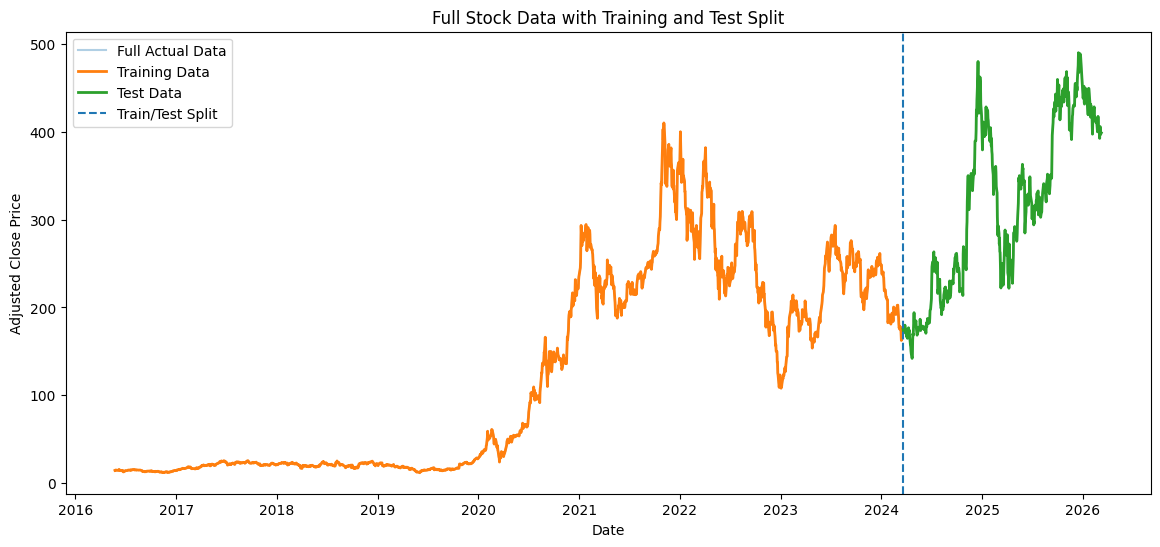

Train rows: 1968
Test rows : 493


In [ ]:
train_size = int(len(df) * TRAIN_SPLIT)

train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Adj Close'], label='Full Actual Data', alpha=0.35)
plt.plot(train_df['Date'], train_df['Adj Close'], label='Training Data', linewidth=2)
plt.plot(test_df['Date'], test_df['Adj Close'], label='Test Data', linewidth=2)

split_date = test_df['Date'].iloc[0]
plt.axvline(split_date, linestyle='--', label='Train/Test Split')

plt.title('Full Stock Data with Training and Test Split')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.show()

print("Train rows:", len(train_df))
print("Test rows :", len(test_df))

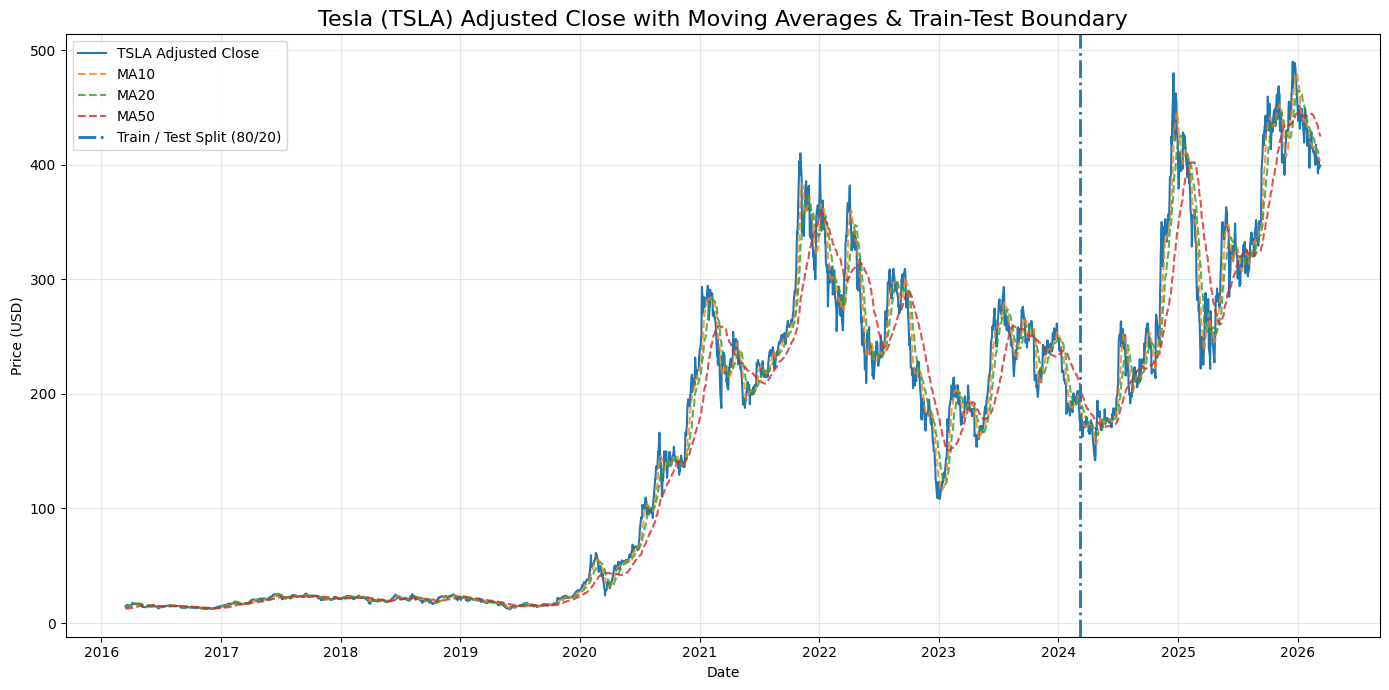

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load prepared Phase 3 dataset
FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/data1010/TSLA_ml_ready.csv"
df = pd.read_csv(FILE_PATH)

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Train-test split point
split_index = int(len(df) * 0.8)
split_date = df['Date'].iloc[split_index]

# Plot
plt.figure(figsize=(14, 7))

# Actual adjusted close
plt.plot(df['Date'], df['Adj Close'], label='TSLA Adjusted Close', linewidth=1.5)

# Moving averages from prepared data
plt.plot(df['Date'], df['MA10'], label='MA10', linestyle='--', alpha=0.8)
plt.plot(df['Date'], df['MA20'], label='MA20', linestyle='--', alpha=0.8)
plt.plot(df['Date'], df['MA50'], label='MA50', linestyle='--', alpha=0.8)

# Train/test boundary
plt.axvline(x=split_date, linestyle='-.', linewidth=2, label='Train / Test Split (80/20)')

# Labels
plt.title('Tesla (TSLA) Adjusted Close with Moving Averages & Train-Test Boundary', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

train_features_scaled = feature_scaler.fit_transform(train_df[FEATURE_COLUMNS])
test_features_scaled = feature_scaler.transform(test_df[FEATURE_COLUMNS])

train_target_scaled = target_scaler.fit_transform(train_df[[TARGET_COLUMN]])
test_target_scaled = target_scaler.transform(test_df[[TARGET_COLUMN]])

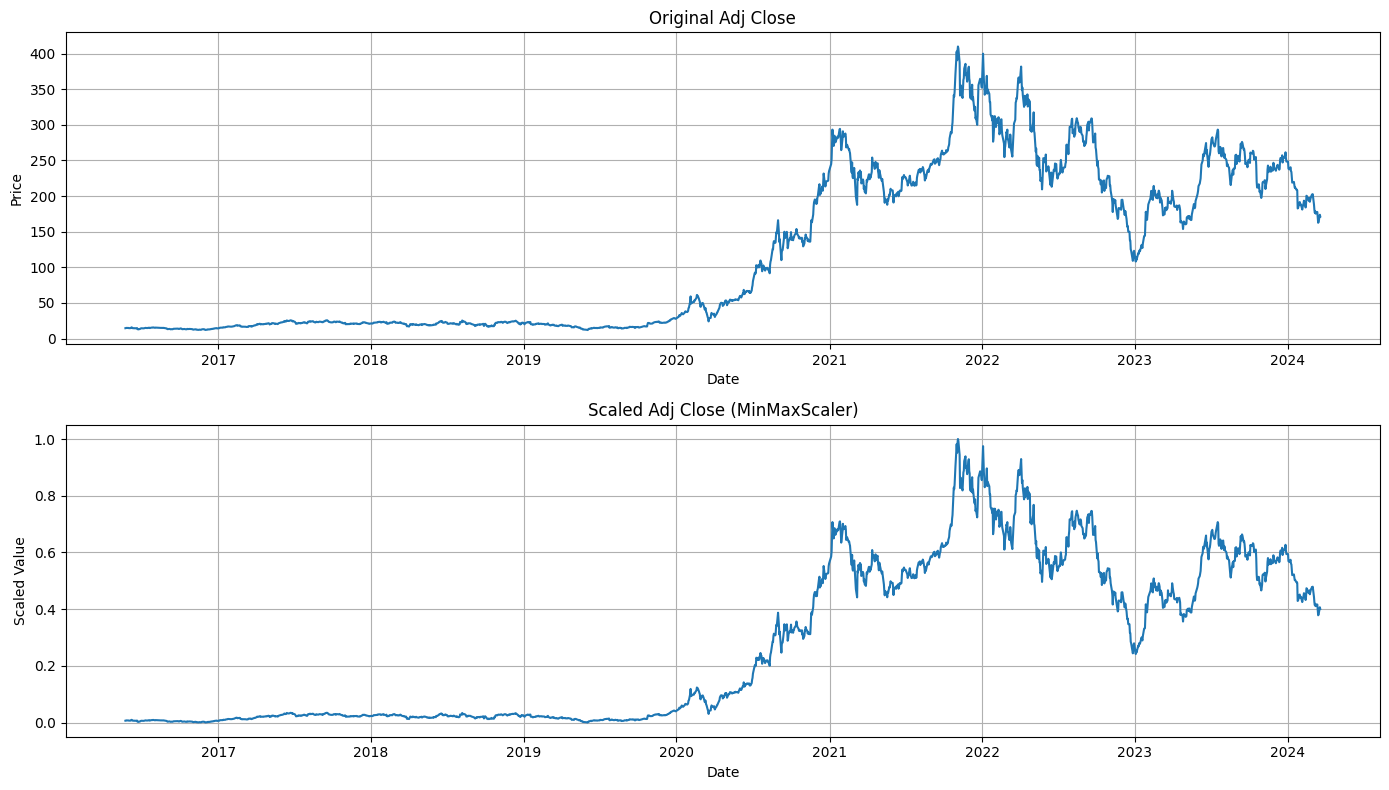

In [ ]:
import matplotlib.pyplot as plt

feature_name = 'Adj Close'
feature_index = FEATURE_COLUMNS.index(feature_name)

plt.figure(figsize=(14, 8))

# Original
plt.subplot(2, 1, 1)
plt.plot(
    train_df['Date'].reset_index(drop=True),
    train_df[feature_name].reset_index(drop=True)
)
plt.title(f'Original {feature_name}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)

# Scaled
plt.subplot(2, 1, 2)
plt.plot(
    train_df['Date'].reset_index(drop=True),
    train_features_scaled[:, feature_index]
)
plt.title(f'Scaled {feature_name} (MinMaxScaler)')
plt.xlabel('Date')
plt.ylabel('Scaled Value')
plt.grid(True)

plt.tight_layout()
plt.show()

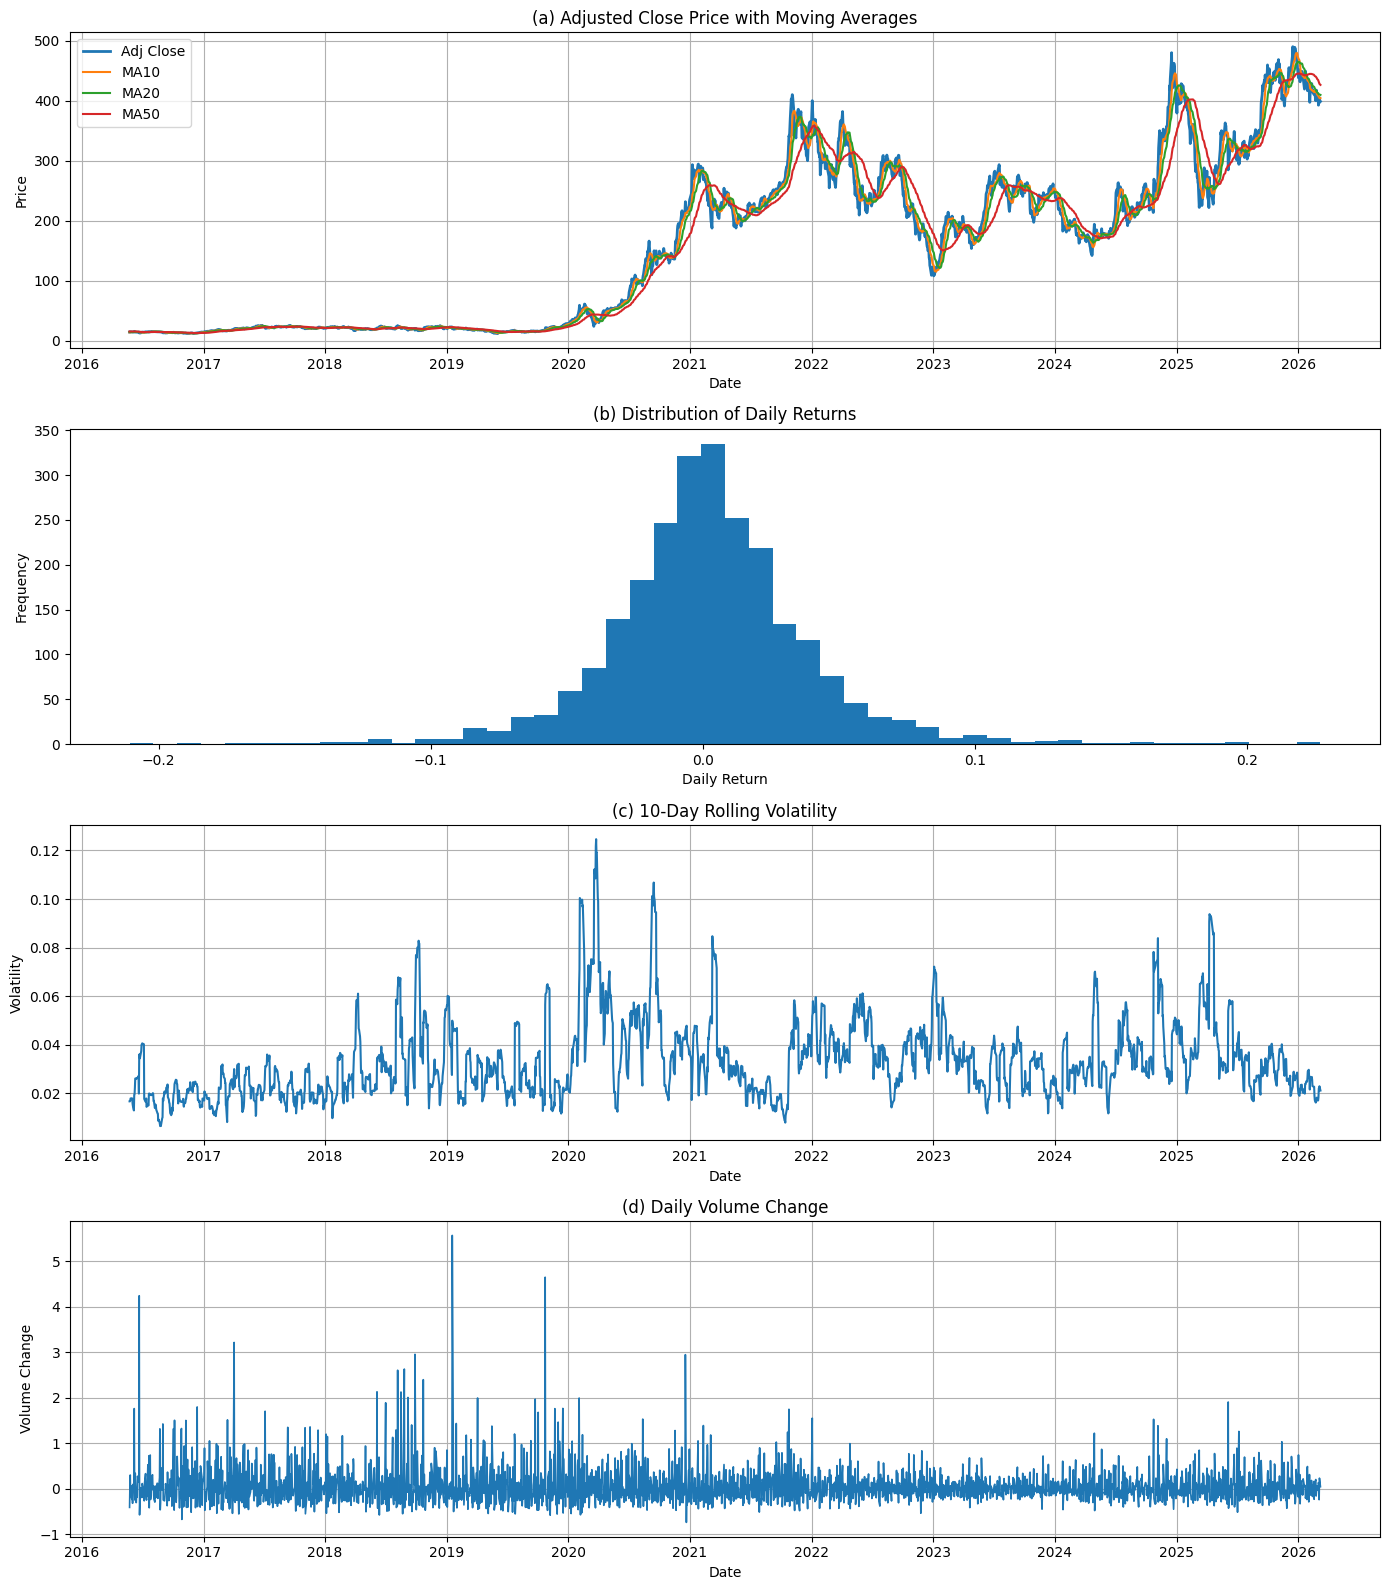

In [ ]:
import matplotlib.pyplot as plt

# Make sure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

plt.figure(figsize=(14, 16))

# -----------------------------
# (a) Price + Moving Averages
# -----------------------------
plt.subplot(4, 1, 1)
plt.plot(df['Date'], df['Adj Close'], label='Adj Close', linewidth=2)
plt.plot(df['Date'], df['MA10'], label='MA10', linewidth=1.5)
plt.plot(df['Date'], df['MA20'], label='MA20', linewidth=1.5)
plt.plot(df['Date'], df['MA50'], label='MA50', linewidth=1.5)
plt.title('(a) Adjusted Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

# -----------------------------
# (b) Daily Returns Histogram
# -----------------------------
plt.subplot(4, 1, 2)
plt.hist(df['Return'].dropna(), bins=50)
plt.title('(b) Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(False)

# -----------------------------
# (c) 10-Day Rolling Volatility
# -----------------------------
plt.subplot(4, 1, 3)
plt.plot(df['Date'], df['Volatility10'], linewidth=1.5)
plt.title('(c) 10-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True)

# -----------------------------
# (d) Volume Change
# -----------------------------
plt.subplot(4, 1, 4)
plt.plot(df['Date'], df['Volume_Change'], linewidth=1.2)
plt.title('(d) Daily Volume Change')
plt.xlabel('Date')
plt.ylabel('Volume Change')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def create_price_sequences(features, targets, lookback):
    X, y = [], []
    for i in range(lookback, len(features)):
        X.append(features[i - lookback:i])
        y.append(targets[i])
    return np.array(X), np.array(y)

In [ ]:
X_train, y_train = create_price_sequences(train_features_scaled, train_target_scaled, LOOKBACK)
X_test, y_test = create_price_sequences(test_features_scaled, test_target_scaled, LOOKBACK)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1908, 60, 7)
y_train shape: (1908, 1)
X_test shape : (433, 60, 7)
y_test shape : (433, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_price_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.1),
        GRU(32),
        Dropout(0.1),
        Dense(16, activation='relu'),
        Dense(1)   # regression output
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_price_model((X_train.shape[1], X_train.shape[2]))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,385 (110.88 KB)

 Trainable params: 28,385 (110.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0490 - mae: 0.1625 - val_loss: 0.0056 - val_mae: 0.0566 - learning_rate: 5.0000e-04
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0110 - mae: 0.0778 - val_loss: 0.0072 - val_mae: 0.0656 - learning_rate: 5.0000e-04
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0108 - mae: 0.0764 - val_loss: 0.0056 - val_mae: 0.0550 - learning_rate: 5.0000e-04
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0102 - mae: 0.0727 - val_loss: 0.0059 - val_mae: 0.0578 - learning_rate: 2.5000e-04
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0098 - mae: 0.0717 - val_loss: 0.0056 - val_mae: 0.0560 - learning_rate: 2.5000e-04
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0098 - mae: 0.0718 - val_loss: 0.0056 - val_mae: 0.0558 - learning_rate: 1.2500e-04
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0100 - mae: 0.0721 - val_loss: 0.0056 - val_mae: 0.0553 - learning_ra

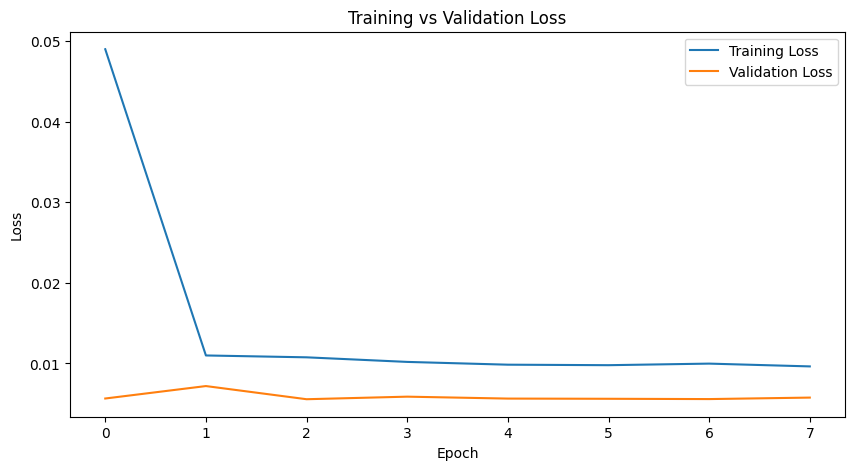

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

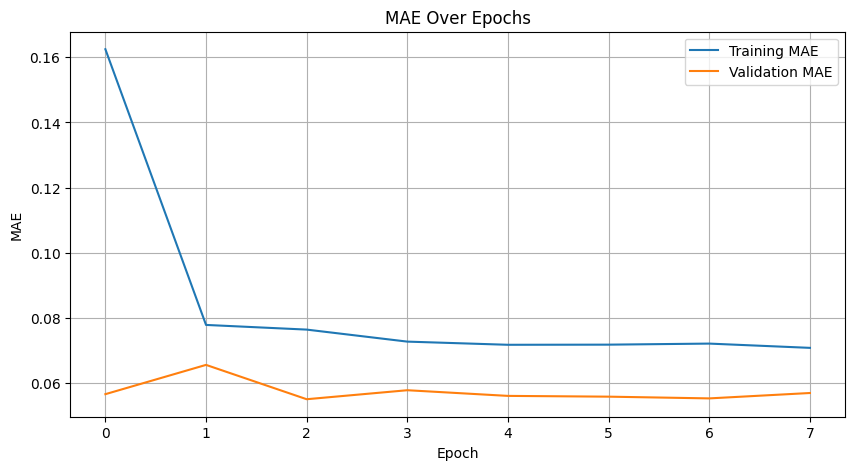

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

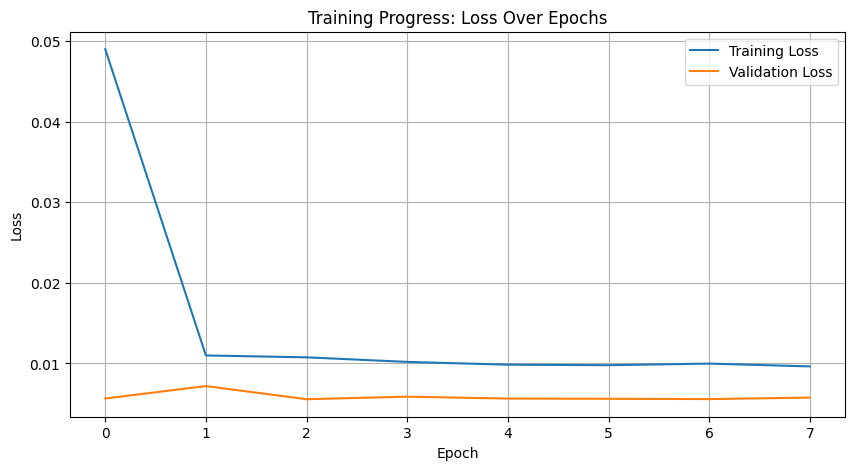

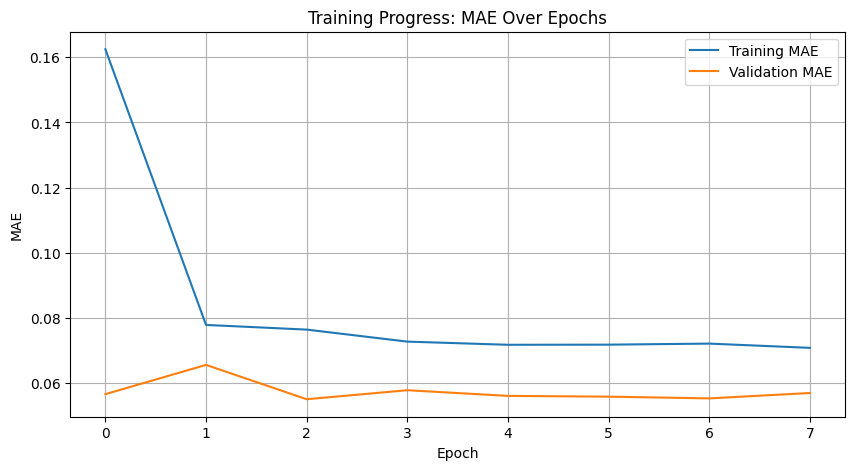

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training Progress: Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training Progress: MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

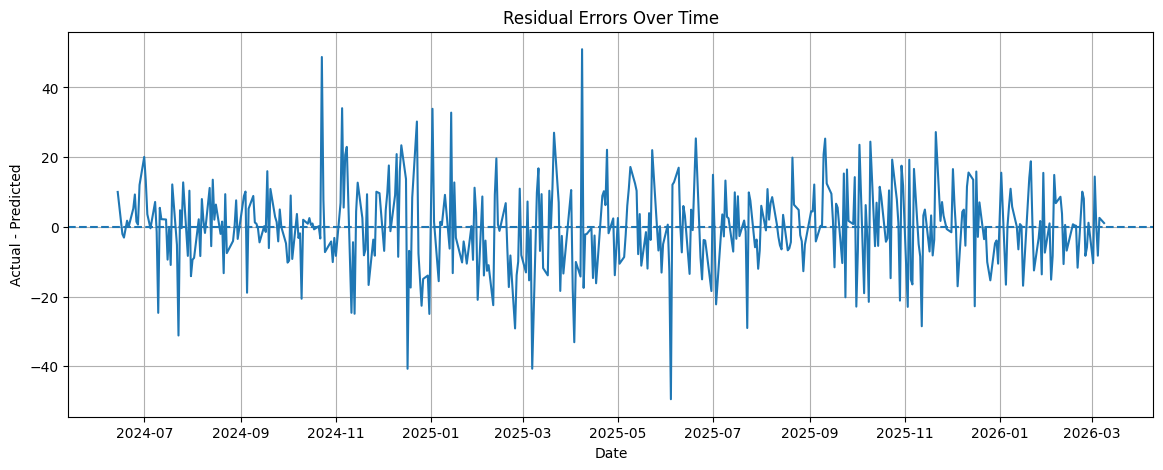

In [ ]:
residuals = results_df['Actual Price'] - results_df['Predicted Price']

plt.figure(figsize=(14, 5))
plt.plot(results_df['Date'], residuals)
plt.axhline(0, linestyle='--')
plt.title('Residual Errors Over Time')
plt.xlabel('Date')
plt.ylabel('Actual - Predicted')
plt.grid(True)
plt.show()

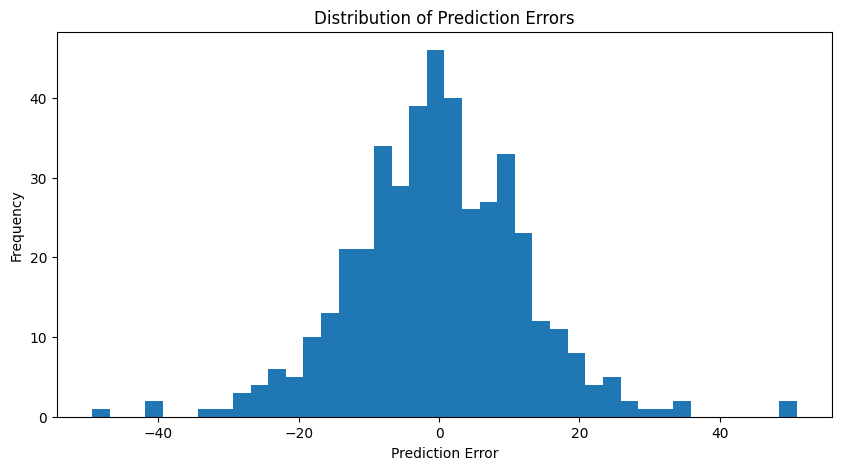

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=40)
plt.title('Distribution of Prediction Errors')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

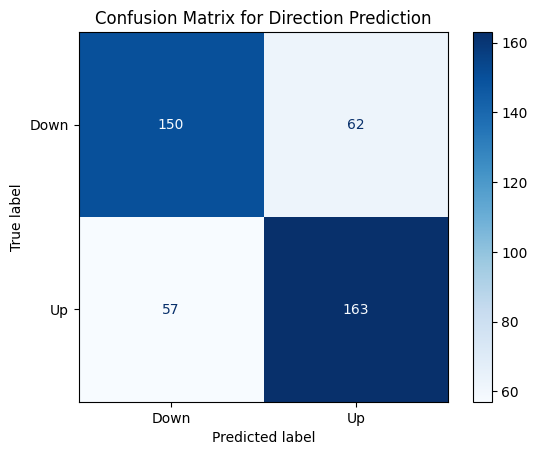

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred_direction = (y_pred_prices[1:] > y_pred_prices[:-1]).astype(int)
actual_direction = (y_actual_prices[1:] > y_actual_prices[:-1]).astype(int)

cm = confusion_matrix(actual_direction, pred_direction)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Direction Prediction')
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

pred_direction = (y_pred_prices[1:] > y_pred_prices[:-1]).astype(int)
actual_direction = (y_actual_prices[1:] > y_actual_prices[:-1]).astype(int)

precision = precision_score(actual_direction, pred_direction)
recall = recall_score(actual_direction, pred_direction)
f1 = f1_score(actual_direction, pred_direction)

print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Precision: 0.7244444444444444
Recall   : 0.740909090909091
F1-score : 0.7325842696629213


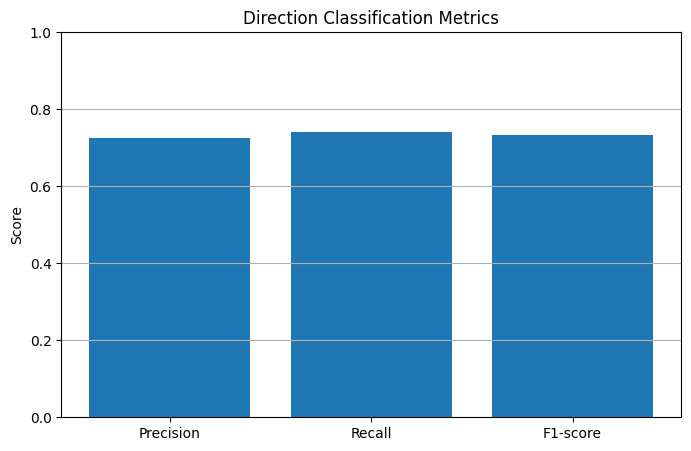

In [ ]:
metrics = ['Precision', 'Recall', 'F1-score']
values = [precision, recall, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values)
plt.title('Direction Classification Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

In [ ]:
y_pred_scaled = model.predict(X_test)

print("Predicted scaled shape:", y_pred_scaled.shape)
print("Actual scaled shape   :", y_test.shape)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Predicted scaled shape: (433, 1)
Actual scaled shape   : (433, 1)


In [ ]:
# ================================
# Convert predicted RETURNS → PRICE
# ================================

# Step 1: inverse transform returns
y_pred_returns = target_scaler.inverse_transform(y_pred_scaled).flatten()
y_actual_returns = target_scaler.inverse_transform(y_test).flatten()

# Step 2: align base prices correctly
# For each predicted target in the test set, use the previous day's Adj Close
base_prices = test_df['Adj Close'].iloc[LOOKBACK-1:-1].values

print("base_prices length     :", len(base_prices))
print("y_pred_returns length  :", len(y_pred_returns))
print("y_actual_returns length:", len(y_actual_returns))

# Step 3: reconstruct prices
y_pred_prices = base_prices * (1 + y_pred_returns)
y_actual_prices = base_prices * (1 + y_actual_returns)

print("First 10 predicted prices:", y_pred_prices[:10])
print("First 10 actual prices   :", y_actual_prices[:10])

base_prices length     : 433
y_pred_returns length  : 433
y_actual_returns length: 433
First 10 predicted prices: [182.11732324 177.61464701 187.18084989 184.55657275 181.14203489
 182.53858376 182.07869412 186.87138029 196.1840213  197.35903257]
First 10 actual prices   : [192.13627622 175.55979121 184.10409231 186.32607992 181.14339798
 187.79123258 191.3703384  188.35177869 196.82755523 209.3721443 ]


In [ ]:
mae = mean_absolute_error(y_actual_prices, y_pred_prices)
mse = mean_squared_error(y_actual_prices, y_pred_prices)
rmse = np.sqrt(mse)
r2 = r2_score(y_actual_prices, y_pred_prices)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 9.3594
MSE : 153.5166
RMSE: 12.3902
R²  : 0.9785


In [ ]:
test_dates = test_df['Date'].iloc[LOOKBACK:].reset_index(drop=True)

results_df = pd.DataFrame({
    'Date': test_dates,
    'Base Price': base_prices,
    'Actual Return': y_actual_returns,
    'Predicted Return': y_pred_returns,
    'Actual Price': y_actual_prices,
    'Predicted Price': y_pred_prices
})

results_df.head(20)

,Date,Base Price,Actual Return,Predicted Return,Actual Price,Predicted Price
0,2024-06-14,182.470001,0.052975,-0.001933,192.136276,182.117323
1,2024-06-17,178.009995,-0.013764,-0.002221,175.559791,177.614647
2,2024-06-18,187.440002,-0.017797,-0.001383,184.104092,187.180850
3,2024-06-20,184.860001,0.007931,-0.001641,186.326080,184.556573
4,2024-06-21,181.570007,-0.002350,-0.002357,181.143398,181.142035
5,2024-06-24,183.009995,0.026126,-0.002576,187.791233,182.538584
6,2024-06-25,182.580002,0.048145,-0.002746,191.370338,182.078694
7,2024-06-26,187.350006,0.005347,-0.002555,188.351779,186.871380
8,2024-06-27,196.369995,0.002330,-0.000947,196.827555,196.184021
9,2024-06-28,197.419998,0.060542,-0.000309,209.372144,197.359033


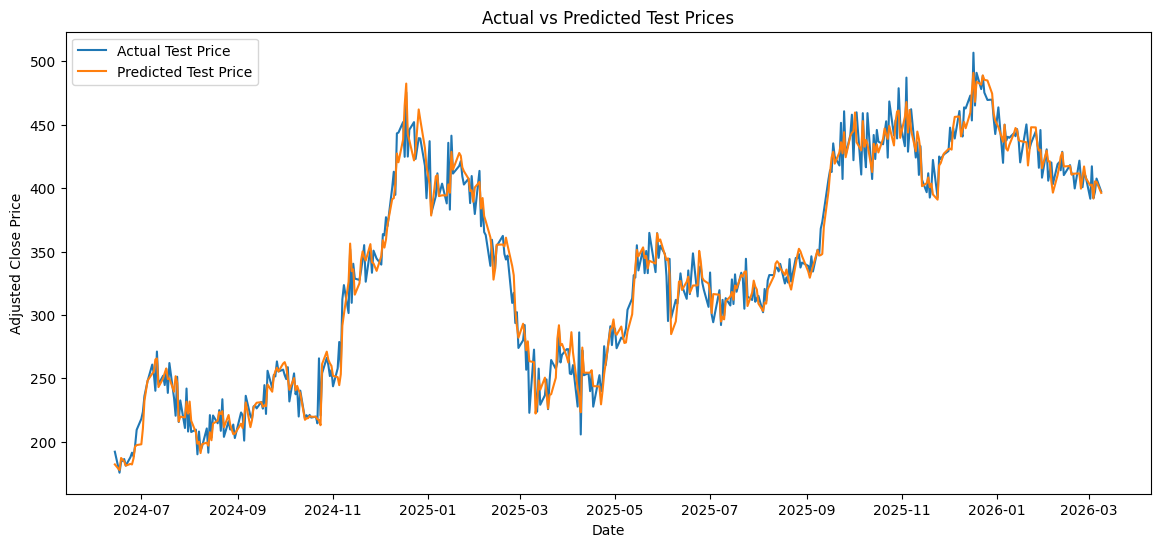

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(results_df['Date'], results_df['Actual Price'], label='Actual Test Price')
plt.plot(results_df['Date'], results_df['Predicted Price'], label='Predicted Test Price')

plt.title('Actual vs Predicted Test Prices')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.show()

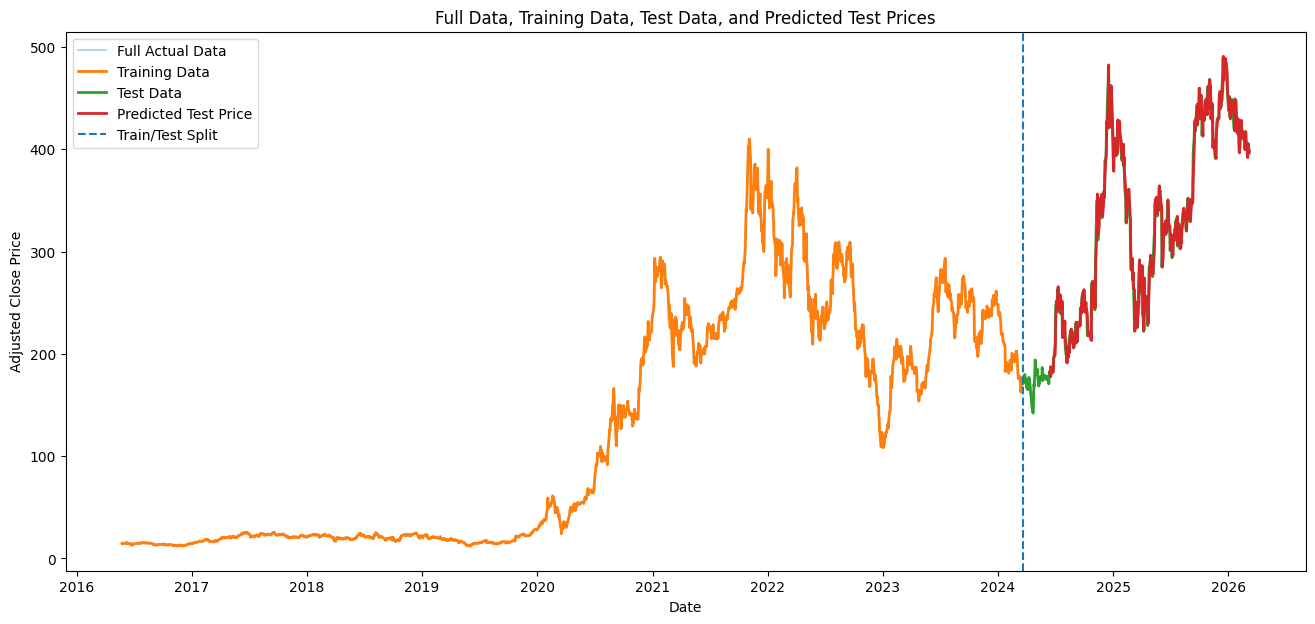

In [ ]:
plt.figure(figsize=(16, 7))

# Full actual data
plt.plot(df['Date'], df['Adj Close'], label='Full Actual Data', alpha=0.3)

# Highlight training data
plt.plot(train_df['Date'], train_df['Adj Close'], label='Training Data', linewidth=2)

# Highlight actual test data
plt.plot(test_df['Date'], test_df['Adj Close'], label='Test Data', linewidth=2)

# Predicted prices on test region
plt.plot(results_df['Date'], results_df['Predicted Price'], label='Predicted Test Price', linewidth=2)

# Split line
split_date = test_df['Date'].iloc[0]
plt.axvline(split_date, linestyle='--', label='Train/Test Split')

plt.title('Full Data, Training Data, Test Data, and Predicted Test Prices')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.show()

In [ ]:
print("Predicted UP %:", pred_direction.mean() * 100)
print("Actual UP %   :", actual_direction.mean() * 100)

Predicted UP %: 52.083333333333336
Actual UP %   : 50.92592592592593


In [ ]:
# ================================
# Direction Accuracy (UPDATED)
# ================================

# Compare movement between consecutive predicted prices
pred_direction = (y_pred_prices[1:] > y_pred_prices[:-1]).astype(int)
actual_direction = (y_actual_prices[1:] > y_actual_prices[:-1]).astype(int)

from sklearn.metrics import accuracy_score
direction_acc = accuracy_score(actual_direction, pred_direction)

print("Direction Accuracy:", direction_acc)

Direction Accuracy: 0.7245370370370371


In [ ]:
# ================================
# Direction Accuracy (UPDATED)
# ================================

pred_direction = (y_pred_prices[1:] > y_pred_prices[:-1]).astype(int)
actual_direction = (y_actual_prices[1:] > y_actual_prices[:-1]).astype(int)

from sklearn.metrics import accuracy_score
direction_acc = accuracy_score(actual_direction, pred_direction)

print("Direction Accuracy:", direction_acc)
print("Predicted UP %:", pred_direction.mean() * 100)
print("Actual UP %   :", actual_direction.mean() * 100)

Direction Accuracy: 0.7245370370370371
Predicted UP %: 52.083333333333336
Actual UP %   : 50.92592592592593


In [ ]:
# ================================
# Predict NEXT DAY PRICE
# ================================

# Step 1: Get last 60 days of features
last_sequence = df[FEATURE_COLUMNS].iloc[-LOOKBACK:].values

# Step 2: Scale using same scaler
last_sequence_scaled = feature_scaler.transform(last_sequence)

# Step 3: Reshape for model (1 sample, 60 timesteps, features)
last_sequence_scaled = np.reshape(last_sequence_scaled, (1, LOOKBACK, len(FEATURE_COLUMNS)))

# Step 4: Predict (scaled)
next_day_scaled = model.predict(last_sequence_scaled)

# Step 5: Convert back to real price
next_day_price = target_scaler.inverse_transform(next_day_scaled)

# Step 6: Print result
last_date = df['Date'].iloc[-1]

print("Last Date in Data:", last_date)
print("Last Known Price :", df['Adj Close'].iloc[-1])
print("Predicted Next Day Price:", next_day_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Last Date in Data: 2026-03-09 00:00:00
Last Known Price : 398.6799926757813
Predicted Next Day Price: -0.0012814888


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ================================
# Predict NEXT DAY PRICE (FIXED)
# ================================

from pandas.tseries.offsets import BDay

# Make sure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Step 1: get the last LOOKBACK rows of features
last_sequence_df = df[FEATURE_COLUMNS].iloc[-LOOKBACK:].copy()
last_sequence = last_sequence_df.values

# Step 2: scale features
last_sequence_scaled = feature_scaler.transform(last_sequence)

# Step 3: reshape for model
last_sequence_scaled = np.reshape(
    last_sequence_scaled,
    (1, LOOKBACK, len(FEATURE_COLUMNS))
)

# Step 4: predict scaled return
next_day_scaled = model.predict(last_sequence_scaled, verbose=0)

# Step 5: inverse transform to get predicted RETURN
predicted_return = target_scaler.inverse_transform(next_day_scaled)[0][0]

# Step 6: convert return to predicted next-day price
last_known_price = df['Adj Close'].iloc[-1]
predicted_next_day_price = last_known_price * (1 + predicted_return)

# Step 7: compute next business day date
last_date_in_model_data = df['Date'].iloc[-1]
predicted_date = last_date_in_model_data + BDay(1)

# Step 8: print results
print("Last Date in Model Data :", last_date_in_model_data.date())
print("Last Known Price        :", round(last_known_price, 4))
print("Predicted Return        :", round(predicted_return, 6))
print("Predicted Date          :", predicted_date.date())
print("Predicted Next Day Price:", round(predicted_next_day_price, 4))

Last Date in Model Data : 2026-03-09
Last Known Price        : 398.68
Predicted Return        : -0.001281
Predicted Date          : 2026-03-10
Predicted Next Day Price: 398.1691


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ================================
# Predict NEXT DAY PRICE (4,5)
# ================================

# Ensure date format
df['Date'] = pd.to_datetime(df['Date'])

# Step 1: Get last LOOKBACK days of features
last_sequence = df[FEATURE_COLUMNS].iloc[-LOOKBACK:].values

# Step 2: Scale features
last_sequence_scaled = feature_scaler.transform(last_sequence)

# Step 3: Reshape for model
last_sequence_scaled = np.reshape(last_sequence_scaled, (1, LOOKBACK, len(FEATURE_COLUMNS)))

# Step 4: Predict scaled return
next_day_scaled = model.predict(last_sequence_scaled, verbose=0)

# Step 5: Convert scaled return back to real return
pred_return = target_scaler.inverse_transform(next_day_scaled)[0][0]

# Step 6: Convert return to price
last_known_price = df['Adj Close'].iloc[-1]
predicted_next_day_price = last_known_price * (1 + pred_return)

# Step 7: Get next date
last_date = df['Date'].iloc[-1]
next_date = last_date + pd.Timedelta(days=1)

# Step 8: Print result
print("Last Date in Data :", last_date)
print("Last Known Price  :", last_known_price)
print("Predicted Return  :", pred_return)
print("Predicted Date    :", next_date)
print("Predicted Next Day Price:", predicted_next_day_price)

Last Date in Data : 2026-03-09 00:00:00
Last Known Price  : 398.6799926757813
Predicted Return  : -0.0012814888
Predicted Date    : 2026-03-10 00:00:00
Predicted Next Day Price: 398.16908431991766


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ==========================================
# Predict NEXT 14 DAYS with DATES
# ==========================================

future_days = 14
future_predictions = []
future_dates = []

current_sequence = df[FEATURE_COLUMNS].iloc[-LOOKBACK:].copy()
df['Date'] = pd.to_datetime(df['Date'])
last_date = df['Date'].iloc[-1]

for i in range(future_days):
    # Scale
    scaled_seq = feature_scaler.transform(current_sequence)
    scaled_seq = np.reshape(scaled_seq, (1, LOOKBACK, len(FEATURE_COLUMNS)))

    # Predict
    pred_scaled = model.predict(scaled_seq)
    pred_return = target_scaler.inverse_transform(pred_scaled)[0][0]

    last_price = current_sequence.iloc[-1]['Adj Close']
    pred_price = last_price * (1 + pred_return)

    # Store prediction
    future_predictions.append(pred_price)

    # Create next date (skip weekends optionally later)
    next_date = last_date + pd.Timedelta(days=1)
    future_dates.append(next_date)
    last_date = next_date

    # ===============================
    # Create new row (approximation)
    # ===============================

    new_row = current_sequence.iloc[-1].copy()

    # Update price
    new_row['Adj Close'] = pred_price

    # Update derived features (approximate)
    new_row['Return'] = (pred_price - current_sequence.iloc[-1]['Adj Close']) / current_sequence.iloc[-1]['Adj Close']
    new_row['MA10'] = current_sequence['Adj Close'].iloc[-10:].mean()
    new_row['MA20'] = current_sequence['Adj Close'].iloc[-20:].mean()
    new_row['MA50'] = current_sequence['Adj Close'].iloc[-50:].mean()
    new_row['Volatility10'] = current_sequence['Return'].iloc[-10:].std()
    new_row['Volume_Change'] = 0  # assume stable volume

    # Update sequence
    current_sequence = pd.concat([current_sequence.iloc[1:], new_row.to_frame().T], ignore_index=True)

# Convert to DataFrame
future_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Price': future_predictions
})

print(future_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
         Date  Predicted Price
0  2026-03-10       398.169084
1  2026-03-11       397.672406
2  2026-03-12       397.168122
3  2026-03-13       396.645705
4  2026-03-14       396.098607
5  2026-03-15       395.519683
6  2026-03-16       394.905347
7  2026-03-17       394.238204
8  2026-03-18       393.485690
9  2026-03-19       392.651423
10 2026-03-20       391.699355
11 2026-03-21       390.614765
12 2026-03-22       389.388548
13 2026-03-23       388.013927


In [ ]:
# ==========================================
# Predict NEXT 14 DAYS with DATES (4,5)
# ==========================================

future_days = 14
future_predictions = []
future_dates = []

current_sequence = df[FEATURE_COLUMNS].iloc[-LOOKBACK:].copy()
last_date = df['Date'].iloc[-1]

for i in range(future_days):
    # Scale current sequence
    scaled_seq = feature_scaler.transform(current_sequence)
    scaled_seq = np.reshape(scaled_seq, (1, LOOKBACK, len(FEATURE_COLUMNS)))

    # Predict scaled return
    pred_scaled = model.predict(scaled_seq, verbose=0)
    pred_return = target_scaler.inverse_transform(pred_scaled)[0][0]

    # Convert return to price
    last_price = current_sequence.iloc[-1]['Adj Close']
    pred_price = last_price * (1 + pred_return)

    # Store prediction
    future_predictions.append(pred_price)

    # Next date
    next_date = last_date + pd.Timedelta(days=1)
    future_dates.append(next_date)
    last_date = next_date

    # Build next synthetic row
    new_row = current_sequence.iloc[-1].copy()
    new_row['Adj Close'] = pred_price
    new_row['Return'] = (pred_price - current_sequence.iloc[-1]['Adj Close']) / current_sequence.iloc[-1]['Adj Close']
    new_row['MA10'] = current_sequence['Adj Close'].iloc[-10:].mean()
    new_row['MA20'] = current_sequence['Adj Close'].iloc[-20:].mean()
    new_row['MA50'] = current_sequence['Adj Close'].iloc[-50:].mean()
    new_row['Volatility10'] = current_sequence['Return'].iloc[-10:].std()
    new_row['Volume_Change'] = 0

    # Update rolling window
    current_sequence = pd.concat(
        [current_sequence.iloc[1:], new_row.to_frame().T],
        ignore_index=True
    )

# Convert to DataFrame
future_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Price': future_predictions
})

print(future_df)

         Date  Predicted Price
0  2026-03-10       398.169084
1  2026-03-11       397.672406
2  2026-03-12       397.168122
3  2026-03-13       396.645705
4  2026-03-14       396.098607
5  2026-03-15       395.519683
6  2026-03-16       394.905347
7  2026-03-17       394.238204
8  2026-03-18       393.485690
9  2026-03-19       392.651423
10 2026-03-20       391.699355
11 2026-03-21       390.614765
12 2026-03-22       389.388548
13 2026-03-23       388.013927


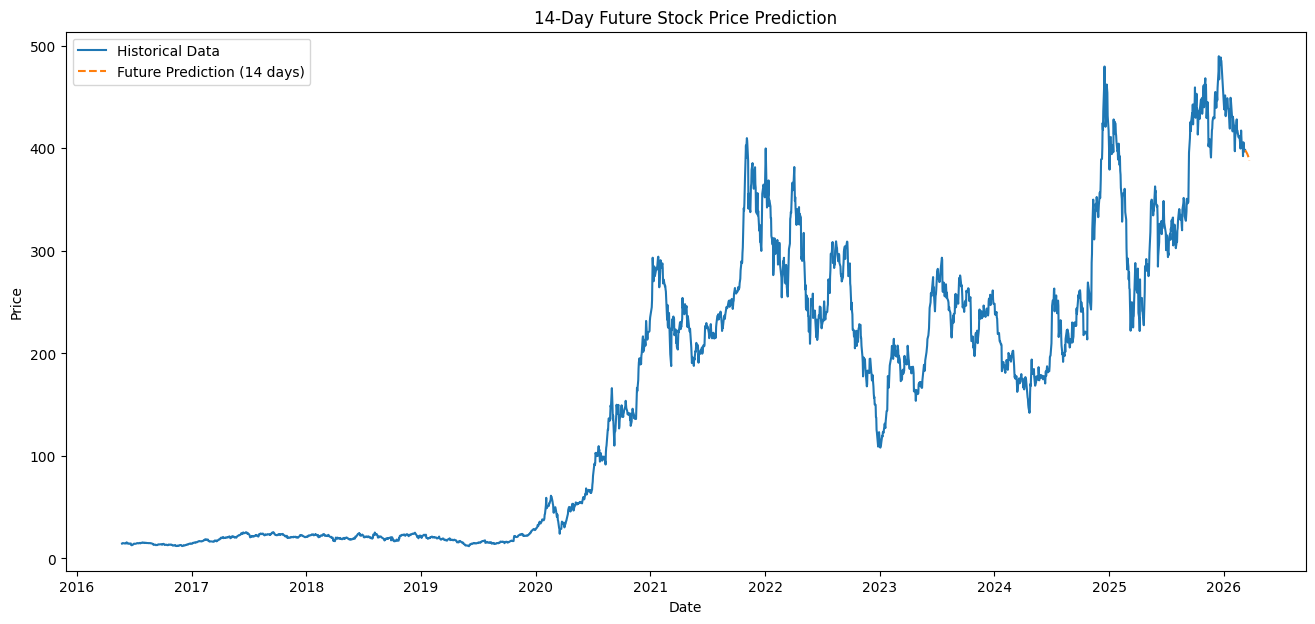

In [ ]:
plt.figure(figsize=(16, 7))

# Actual data
plt.plot(df['Date'], df['Adj Close'], label='Historical Data')

# Future predictions
plt.plot(future_df['Date'], future_df['Predicted Price'], linestyle='--', label='Future Prediction (14 days)')

plt.title('14-Day Future Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
# ==========================================
# Predict NEXT 14 DAYS with DATES
# ==========================================

future_days = 30
future_predictions = []
future_dates = []

current_sequence = df[FEATURE_COLUMNS].iloc[-LOOKBACK:].copy()
df['Date'] = pd.to_datetime(df['Date'])
last_date = df['Date'].iloc[-1]

for i in range(future_days):
    # Scale
    scaled_seq = feature_scaler.transform(current_sequence)
    scaled_seq = np.reshape(scaled_seq, (1, LOOKBACK, len(FEATURE_COLUMNS)))

    # Predict
    pred_scaled = model.predict(scaled_seq)
    pred_return = target_scaler.inverse_transform(pred_scaled)[0][0]

    last_price = current_sequence.iloc[-1]['Adj Close']
    pred_price = last_price * (1 + pred_return)

    # Store prediction
    future_predictions.append(pred_price)

    # Create next date (skip weekends optionally later)
    next_date = last_date + pd.Timedelta(days=1)
    future_dates.append(next_date)
    last_date = next_date

    # ===============================
    # Create new row (approximation)
    # ===============================

    new_row = current_sequence.iloc[-1].copy()

    # Update price
    new_row['Adj Close'] = pred_price

    # Update derived features (approximate)
    new_row['Return'] = (pred_price - current_sequence.iloc[-1]['Adj Close']) / current_sequence.iloc[-1]['Adj Close']
    new_row['MA10'] = current_sequence['Adj Close'].iloc[-10:].mean()
    new_row['MA20'] = current_sequence['Adj Close'].iloc[-20:].mean()
    new_row['MA50'] = current_sequence['Adj Close'].iloc[-50:].mean()
    new_row['Volatility10'] = current_sequence['Return'].iloc[-10:].std()
    new_row['Volume_Change'] = 0  # assume stable volume

    # Update sequence
    current_sequence = pd.concat([current_sequence.iloc[1:], new_row.to_frame().T], ignore_index=True)

# Convert to DataFrame
future_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Price': future_predictions
})

print(future_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━

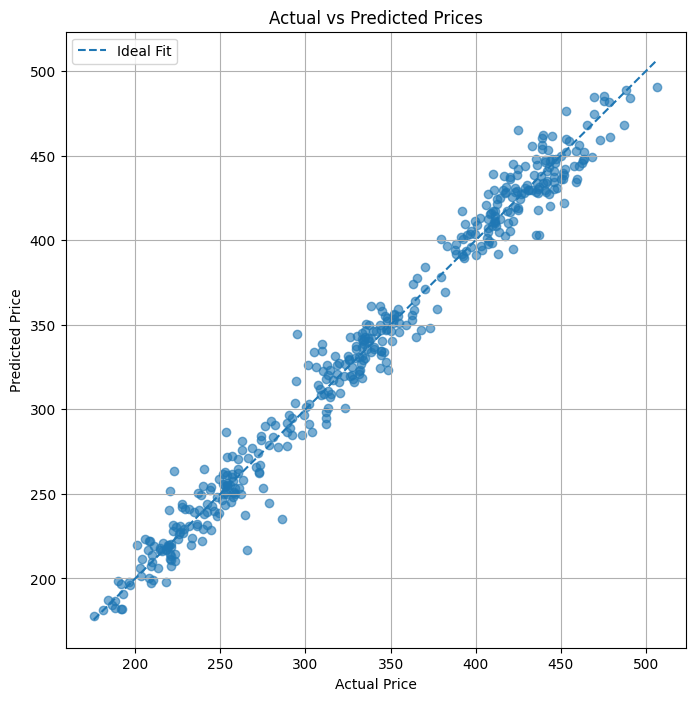

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(y_actual_prices, y_pred_prices, alpha=0.6)

min_val = min(min(y_actual_prices), min(y_pred_prices))
max_val = max(max(y_actual_prices), max(y_pred_prices))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', label='Ideal Fit')

plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.grid(True)
plt.show()

Model Direction Accuracy     : 0.7245370370370371
Always-UP Baseline Accuracy  : 0.5092592592592593
Majority-Class Baseline Acc. : 0.5092592592592593
Random Baseline Accuracy     : 0.5254629629629629


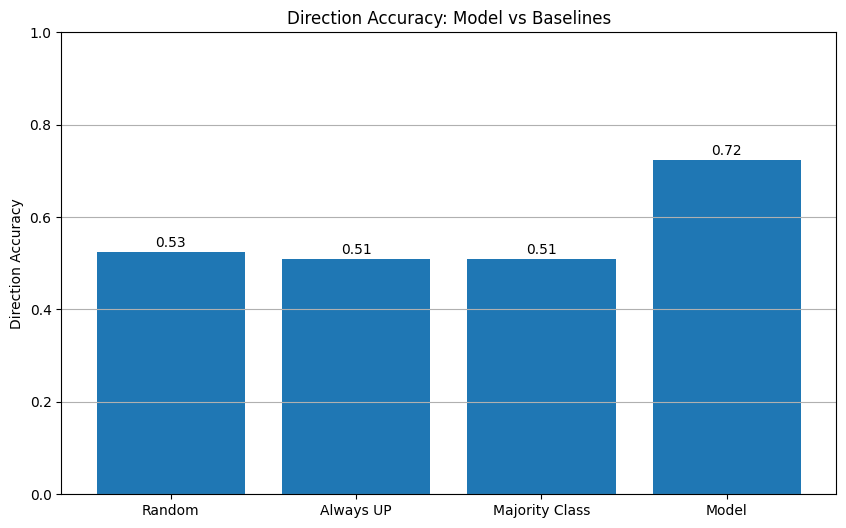

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Convert prices into direction labels
# 1 = UP, 0 = DOWN
# ==========================================
pred_direction = (y_pred_prices[1:] > y_pred_prices[:-1]).astype(int)
actual_direction = (y_actual_prices[1:] > y_actual_prices[:-1]).astype(int)

# ==========================================
# Model Direction Accuracy
# ==========================================
model_direction_acc = accuracy_score(actual_direction, pred_direction)

# ==========================================
# Baseline 1: Always predict UP
# ==========================================
always_up = np.ones_like(actual_direction)
always_up_acc = accuracy_score(actual_direction, always_up)

# ==========================================
# Baseline 2: Majority class baseline
# ==========================================
majority_class = int(actual_direction.mean() >= 0.5)
majority_pred = np.full_like(actual_direction, majority_class)
majority_acc = accuracy_score(actual_direction, majority_pred)

# ==========================================
# Baseline 3: Random guessing
# ==========================================
np.random.seed(42)
random_pred = np.random.randint(0, 2, size=len(actual_direction))
random_acc = accuracy_score(actual_direction, random_pred)

# ==========================================
# Print results
# ==========================================
print("Model Direction Accuracy     :", model_direction_acc)
print("Always-UP Baseline Accuracy  :", always_up_acc)
print("Majority-Class Baseline Acc. :", majority_acc)
print("Random Baseline Accuracy     :", random_acc)

# ==========================================
# Plot graph
# ==========================================
methods = ['Random', 'Always UP', 'Majority Class', 'Model']
accuracies = [random_acc, always_up_acc, majority_acc, model_direction_acc]

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, accuracies)

plt.ylim(0, 1)
plt.ylabel('Direction Accuracy')
plt.title('Direction Accuracy: Model vs Baselines')
plt.grid(axis='y')

# Add values on top of bars
for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{value:.2f}',
        ha='center'
    )

plt.show()

In [ ]:
# ==========================================
# FINAL COMBINED PREDICTION (DIRECTION + PRICE)
# ==========================================

from pandas.tseries.offsets import BDay

# Ensure datetime
df['Date'] = pd.to_datetime(df['Date'])

# Step 1: Get last sequence
last_sequence_df = df[FEATURE_COLUMNS].iloc[-LOOKBACK:].copy()
last_sequence = last_sequence_df.values

# Step 2: Scale
last_sequence_scaled = feature_scaler.transform(last_sequence)
last_sequence_scaled = np.reshape(
    last_sequence_scaled,
    (1, LOOKBACK, len(FEATURE_COLUMNS))
)

# Step 3: Predict return
next_day_scaled = model.predict(last_sequence_scaled, verbose=0)
predicted_return = target_scaler.inverse_transform(next_day_scaled)[0][0]

# Step 4: Convert to price
last_price = df['Adj Close'].iloc[-1]
predicted_price = last_price * (1 + predicted_return)

# Step 5: Determine direction
if predicted_return > 0:
    direction = "UP 📈"
else:
    direction = "DOWN 📉"

# Step 6: Confidence (strength of move)
confidence = abs(predicted_return)

# Step 7: Next business day
last_date = df['Date'].iloc[-1]
predicted_date = last_date + BDay(1)

# Step 8: Output
print("===================================")
print("FINAL MODEL DECISION")
print("===================================")

print("Last Date           :", last_date.date())
print("Prediction Date     :", predicted_date.date())

print("\n--- PRICE ---")
print("Last Price          :", round(last_price, 2))
print("Predicted Price     :", round(predicted_price, 2))

print("\n--- DIRECTION ---")
print("Direction           :", direction)
print("Expected Move       :", f"{predicted_return*100:.2f}%")

print("\n--- CONFIDENCE ---")
print("Strength of Signal  :", f"{confidence*100:.2f}%")

print("===================================")

FINAL MODEL DECISION
Last Date           : 2026-03-09
Prediction Date     : 2026-03-10

--- PRICE ---
Last Price          : 398.68
Predicted Price     : 398.17

--- DIRECTION ---
Direction           : DOWN 📉
Expected Move       : -0.13%

--- CONFIDENCE ---
Strength of Signal  : 0.13%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
baseline_up = (y_actual_prices[1:] > y_actual_prices[:-1]).astype(int)
always_up = np.ones_like(baseline_up)

from sklearn.metrics import accuracy_score
baseline_acc = accuracy_score(baseline_up, always_up)

print("Baseline (Always UP) Accuracy:", baseline_acc)

Baseline (Always UP) Accuracy: 0.5092592592592593


In [ ]:
random_pred = np.random.randint(0, 2, size=len(actual_direction))
baseline_random = accuracy_score(actual_direction, random_pred)

print("Baseline (Random) Accuracy:", baseline_random)

Baseline (Random) Accuracy: 0.5393518518518519


In [ ]:
baseline_pred = base_prices  # assume no movement

mae_baseline = mean_absolute_error(y_actual_prices, baseline_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_actual_prices, baseline_pred))

print("Baseline MAE :", mae_baseline)
print("Baseline RMSE:", rmse_baseline)

Baseline MAE : 9.309618832838723
Baseline RMSE: 12.381990967970099


In [ ]:
import os

BASE_PATH = "project"

MODEL_PATH = os.path.join(BASE_PATH, "models")
DATA_PATH = os.path.join(BASE_PATH, "data")
RESULT_PATH = os.path.join(BASE_PATH, "results")

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(RESULT_PATH, exist_ok=True)

print("Folders created!")

In [ ]:
# Save trained model
model.save(os.path.join(MODEL_PATH, "lstm_model.h5"))

print("Model saved!")

In [ ]:
import joblib

joblib.dump(feature_scaler, os.path.join(MODEL_PATH, "feature_scaler.pkl"))
joblib.dump(target_scaler, os.path.join(MODEL_PATH, "target_scaler.pkl"))

print("Scalers saved!")

In [ ]:
df.to_csv(os.path.join(DATA_PATH, "processed_data.csv"), index=False)

print("Processed data saved!")

In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Actual Price": y_actual_prices,
    "Predicted Price": y_pred_prices
})

results_df.to_csv(os.path.join(RESULT_PATH, "predictions.csv"), index=False)

print("Predictions saved!")

In [ ]:
future_df.to_csv(os.path.join(RESULT_PATH, "future_predictions.csv"), index=False)

print("Future predictions saved!")

In [ ]:
# from tensorflow.keras.models import load_model
# import joblib
# import pandas as pd

# # Load model
# model = load_model("project/models/lstm_model.h5")

# # Load scalers
# feature_scaler = joblib.load("project/models/feature_scaler.pkl")
# target_scaler = joblib.load("project/models/target_scaler.pkl")

# # Load data
# df = pd.read_csv("project/data/processed_data.csv")

# # Load predictions
# results_df = pd.read_csv("project/results/predictions.csv")